# 71 - Model Comparison + Leakage Audit

This notebook compares **all saved models with prediction files**, summarizes key
metrics, visualizes data distribution, and checks for likely leakage.

It is generated by `scripts/build_model_comparison_leakage_notebook.py`.


## Checklist
- Build / load full model inventory (`reports/tables/model_inventory.csv`)
- Locate prediction files for each model directory
- Compute unified flow-level metrics across calibrations
- Compare per-dataset performance and ranking
- Audit split distributions (dataset, class, split balance)
- Run leakage checks (flow/capture overlap across splits)
- Export comparison tables for reports


In [1]:
# --- Setup ---
%matplotlib inline
import os
import sys
import json
import subprocess
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import roc_auc_score, average_precision_score

sns.set_theme(style='whitegrid', font_scale=1.0)
plt.rcParams['figure.dpi'] = 110

ROOT = Path.cwd()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
    os.chdir(ROOT)
sys.path.insert(0, str(ROOT))

ART = ROOT / 'artifacts'
REPORTS = ROOT / 'reports' / 'tables'
REPORTS.mkdir(parents=True, exist_ok=True)

print('Project root:', ROOT)
print('Artifacts:   ', ART)


Project root: C:\Users\scoti\PycharmProjects\ai-vpn-firewall
Artifacts:    C:\Users\scoti\PycharmProjects\ai-vpn-firewall\artifacts


## 1) Build/load model inventory

In [2]:
inv_csv = REPORTS / 'model_inventory.csv'
inv_md = REPORTS / 'model_inventory.md'

if not inv_csv.exists():
    print('Inventory missing. Running scripts/audit_all_models.py ...')
    proc = subprocess.run(
        [sys.executable, str(ROOT / 'scripts' / 'audit_all_models.py')],
        cwd=str(ROOT),
        capture_output=True,
        text=True,
    )
    print(proc.stdout)
    if proc.returncode != 0:
        print(proc.stderr)
        raise RuntimeError('audit_all_models.py failed')

inv = pd.read_csv(inv_csv)
print(f'Inventory rows: {len(inv)}')
display(inv.head(8))

print('\nStatus distribution:')
display(inv['status'].value_counts(dropna=False).rename_axis('status').to_frame('n_dirs'))


Inventory rows: 62


,dir,n_model_files,file_kinds,train_datasets,n_train_flows,n_test_flows,evidence_file,status,note
0,artifacts/balanced_bagging,9,.pkl,"iscx,usbvpn,vnat",49506,8495,predictions.csv,3-DS ✅,NaN
1,artifacts/balanced_bagging_cat,3,.pkl,"iscx,usbvpn,vnat",57971,10846,predictions.csv,3-DS ✅,NaN
2,artifacts/balanced_bagging_firewall_tuned_ense...,9,.pkl,"iscx,usbvpn,vnat",49506,8495,predictions.csv,3-DS ✅,NaN
3,artifacts/balanced_bagging_firewall_tuned_ense...,9,.pkl,"iscx,vnat",16138,1844,predictions.csv,2-DS (by design),Intentional 2-DS validated backup
4,artifacts/balanced_bagging_firewall_tuned_ense...,9,.pkl,"iscx,usbvpn,vnat",49506,8495,predictions.csv,3-DS ✅,NaN
5,artifacts/balanced_bagging_firewall_tuned_ense...,9,.pkl,"iscx,usbvpn,vnat",49506,8495,predictions.csv,3-DS ✅,NaN
6,artifacts/balanced_bagging_firewall_tuned_ense...,9,.pkl,"iscx,usbvpn,vnat",49724,8514,predictions.csv,3-DS ✅,Pre-promotion snapshot (was 2-DS)
7,artifacts/balanced_bagging_lgbm,3,.pkl,"iscx,usbvpn,vnat",57971,10846,predictions.csv,3-DS ✅,NaN



Status distribution:


,n_dirs
status,
3-DS ✅,48
2-DS (by design),14


## 2) Resolve prediction files for all model dirs

In [3]:
def resolve_pred_file(model_dir: Path):
    cands = [
        model_dir / 'predictions.csv',
        model_dir / 'predictions.parquet',
        model_dir / 'test_predictions.parquet',
        model_dir / 'val_predictions.parquet',
    ]
    for c in cands:
        if c.exists():
            return c
    extras = list(model_dir.glob('*.csv')) + list(model_dir.glob('*.parquet'))
    for c in extras:
        try:
            if c.suffix.lower() == '.csv':
                cols = pd.read_csv(c, nrows=0).columns.tolist()
            else:
                cols = pd.read_parquet(c).columns.tolist()
            if 'label' in cols and ('prob_raw' in cols or 'prob_iso' in cols or 'prob_platt' in cols):
                return c
        except Exception:
            continue
    return None

pred_index = []
for _, r in inv.iterrows():
    d = ROOT / str(r['dir'])
    if not d.exists():
        continue
    p = resolve_pred_file(d)
    if p is not None:
        pred_index.append({
            'dir': str(r['dir']),
            'status': r.get('status', ''),
            'note': r.get('note', ''),
            'pred_file': str(p.relative_to(ROOT)),
        })

pred_df = pd.DataFrame(pred_index).sort_values('dir').reset_index(drop=True)
print(f'Model dirs with prediction files: {len(pred_df)}')
display(pred_df.head(20))


Model dirs with prediction files: 62


,dir,status,note,pred_file
0,artifacts/balanced_bagging,3-DS ✅,NaN,artifacts\balanced_bagging\predictions.csv
1,artifacts/balanced_bagging_cat,3-DS ✅,NaN,artifacts\balanced_bagging_cat\predictions.csv
2,artifacts/balanced_bagging_firewall_tuned_ense...,3-DS ✅,NaN,artifacts\balanced_bagging_firewall_tuned_ense...
3,artifacts/balanced_bagging_firewall_tuned_ense...,2-DS (by design),Intentional 2-DS validated backup,artifacts\balanced_bagging_firewall_tuned_ense...
4,artifacts/balanced_bagging_firewall_tuned_ense...,3-DS ✅,NaN,artifacts\balanced_bagging_firewall_tuned_ense...
5,artifacts/balanced_bagging_firewall_tuned_ense...,3-DS ✅,NaN,artifacts\balanced_bagging_firewall_tuned_ense...
6,artifacts/balanced_bagging_firewall_tuned_ense...,3-DS ✅,Pre-promotion snapshot (was 2-DS),artifacts\balanced_bagging_firewall_tuned_ense...
7,artifacts/balanced_bagging_lgbm,3-DS ✅,NaN,artifacts\balanced_bagging_lgbm\predictions.csv
8,artifacts/balanced_bagging_tuned,3-DS ✅,NaN,artifacts\balanced_bagging_tuned\predictions.csv
9,artifacts/balanced_bagging_xgb,3-DS ✅,NaN,artifacts\balanced_bagging_xgb\predictions.csv


## 3) Unified metric extraction across all models

In [4]:
CORE_COLS = ['split', 'dataset', 'label', 'capture_id', 'flow_id', 'prob_raw', 'prob_iso', 'prob_platt']


def read_preds(path: Path) -> pd.DataFrame:
    if path.suffix.lower() == '.csv':
        head = pd.read_csv(path, nrows=0).columns.tolist()
        use = [c for c in CORE_COLS if c in head]
        return pd.read_csv(path, usecols=use)
    cols = pd.read_parquet(path).columns.tolist()
    use = [c for c in CORE_COLS if c in cols]
    return pd.read_parquet(path, columns=use)


def safe_auc(y, p):
    y = pd.Series(y)
    p = pd.Series(p)
    if y.nunique() < 2:
        return np.nan
    return float(roc_auc_score(y, p))


def safe_pr(y, p):
    y = pd.Series(y)
    p = pd.Series(p)
    if y.nunique() < 2:
        return np.nan
    return float(average_precision_score(y, p))


metric_rows = []
dataset_rows = []
size_rows = []

for _, row in pred_df.iterrows():
    model_dir = row['dir']
    pred_path = ROOT / row['pred_file']
    try:
        df = read_preds(pred_path)
    except Exception as e:
        print(f'Failed to read {pred_path}: {e}')
        continue

    if 'label' not in df.columns:
        continue

    # split sizes and label rates
    if 'split' in df.columns:
        for sp, g in df.groupby('split', dropna=False):
            size_rows.append({
                'dir': model_dir,
                'split': sp,
                'n_rows': int(len(g)),
                'vpn_rate': float(g['label'].mean()) if len(g) else np.nan,
                'datasets': ','.join(sorted(g['dataset'].astype(str).unique())) if 'dataset' in g.columns else '',
            })

    # global metrics
    for split in (['train', 'val', 'test'] if 'split' in df.columns else ['all']):
        sub = df[df['split'] == split] if 'split' in df.columns else df
        if len(sub) == 0:
            continue
        for col, cal in [('prob_raw', 'raw'), ('prob_iso', 'iso'), ('prob_platt', 'platt')]:
            if col not in sub.columns:
                continue
            metric_rows.append({
                'dir': model_dir,
                'status': row['status'],
                'split': split,
                'calibration': cal,
                'n': int(len(sub)),
                'n_vpn': int(sub['label'].sum()),
                'auc': safe_auc(sub['label'], sub[col]),
                'pr_auc': safe_pr(sub['label'], sub[col]),
            })

    # per-dataset test metrics (iso preferred)
    if 'split' in df.columns and 'dataset' in df.columns:
        test = df[df['split'] == 'test']
        if len(test) and 'prob_iso' in test.columns:
            for ds, g in test.groupby('dataset'):
                dataset_rows.append({
                    'dir': model_dir,
                    'dataset': str(ds),
                    'n': int(len(g)),
                    'n_vpn': int(g['label'].sum()),
                    'auc_iso': safe_auc(g['label'], g['prob_iso']),
                    'pr_iso': safe_pr(g['label'], g['prob_iso']),
                })

metrics = pd.DataFrame(metric_rows)
per_ds = pd.DataFrame(dataset_rows)
split_sizes = pd.DataFrame(size_rows)

print('metrics rows:', len(metrics))
print('per-dataset rows:', len(per_ds))
print('split-size rows:', len(split_sizes))
display(metrics.head(10))


metrics rows: 531
per-dataset rows: 160
split-size rows: 179


,dir,status,split,calibration,n,n_vpn,auc,pr_auc
0,artifacts/balanced_bagging,3-DS ✅,train,raw,49506,10349,0.998575,0.994357
1,artifacts/balanced_bagging,3-DS ✅,train,iso,49506,10349,0.998019,0.988556
2,artifacts/balanced_bagging,3-DS ✅,train,platt,49506,10349,0.998575,0.994357
3,artifacts/balanced_bagging,3-DS ✅,val,raw,8861,275,0.982945,0.844190
4,artifacts/balanced_bagging,3-DS ✅,val,iso,8861,275,0.986596,0.830973
5,artifacts/balanced_bagging,3-DS ✅,val,platt,8861,275,0.982945,0.844190
6,artifacts/balanced_bagging,3-DS ✅,test,raw,8495,657,0.987611,0.890540
7,artifacts/balanced_bagging,3-DS ✅,test,iso,8495,657,0.984563,0.859898
8,artifacts/balanced_bagging,3-DS ✅,test,platt,8495,657,0.987611,0.890540
9,artifacts/balanced_bagging_cat,3-DS ✅,train,raw,57971,9135,0.998435,0.990445


## 4) Model ranking and comparison plots

Top models by test AUC (iso):


,dir,status,n,n_vpn,auc,pr_auc
0,artifacts/ensemble/diverse_bagging_robust9,3-DS ✅,9384,1289,0.9912,0.9646
1,artifacts/experiments/exp_b_balanced,3-DS ✅,8733,782,0.9885,0.8964
2,artifacts/experiments/exp_b_balanced_sample,3-DS ✅,8495,657,0.9859,0.8602
3,artifacts/balanced_bagging,3-DS ✅,8495,657,0.9846,0.8599
4,artifacts/ensemble/diverse_bagging_robust,3-DS ✅,8495,657,0.9842,0.8659
5,artifacts/experiments/exp_f1_light_balance,3-DS ✅,8733,782,0.9834,0.8778
6,artifacts/balanced_bagging_firewall_tuned_ense...,3-DS ✅,8495,657,0.9825,0.8513
7,artifacts/balanced_bagging_firewall_tuned_ense...,3-DS ✅,8495,657,0.9825,0.8513
8,artifacts/balanced_bagging_firewall_tuned_ense...,3-DS ✅,8495,657,0.9825,0.8513
9,artifacts/ensemble/balanced_ensemble_robust9,3-DS ✅,3351,1251,0.9822,0.9771


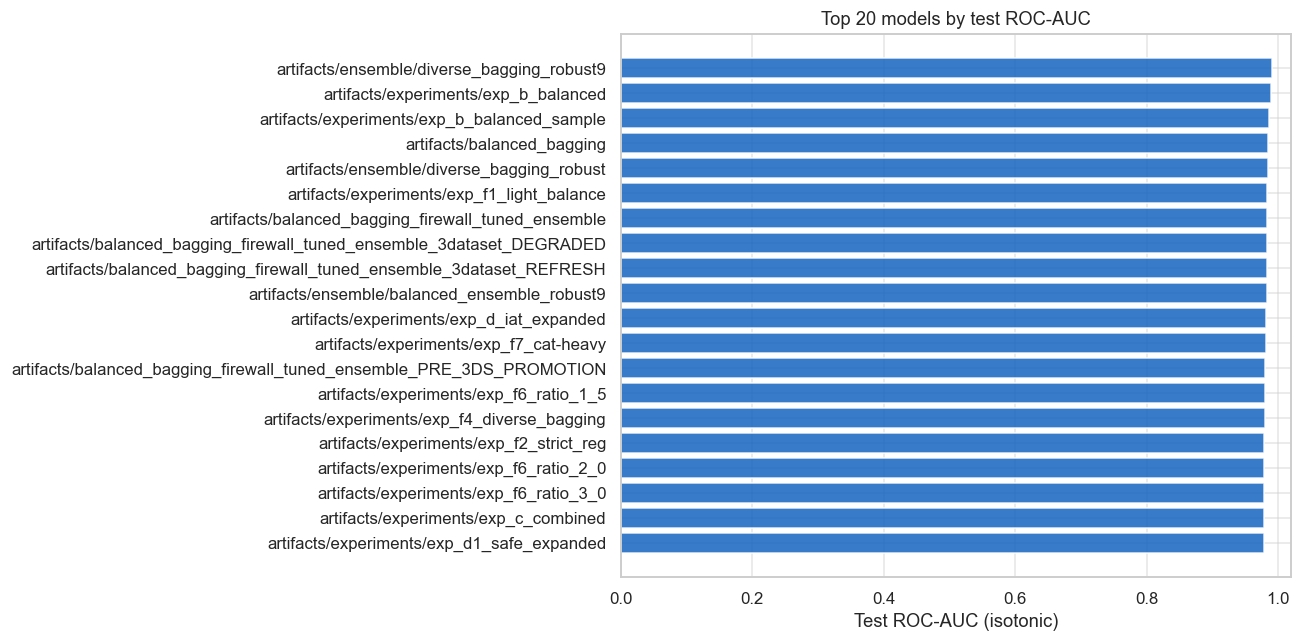

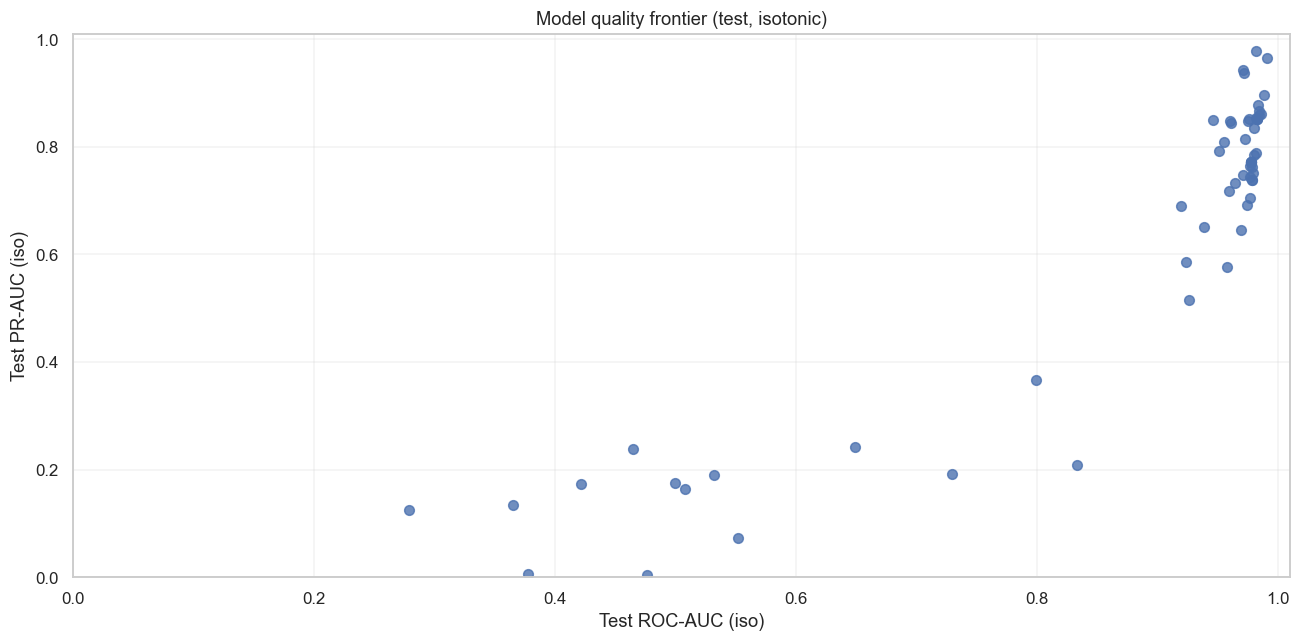

In [5]:
test_iso = metrics[(metrics['split'] == 'test') & (metrics['calibration'] == 'iso')].copy()
ranked = test_iso.sort_values(['auc', 'pr_auc'], ascending=False).reset_index(drop=True)

print('Top models by test AUC (iso):')
display(ranked[['dir', 'status', 'n', 'n_vpn', 'auc', 'pr_auc']].head(25).round(4))

fig, ax = plt.subplots(figsize=(12, 6))
show_n = min(20, len(ranked))
plot_df = ranked.head(show_n).iloc[::-1]
ax.barh(plot_df['dir'], plot_df['auc'], color='#1565C0', alpha=0.85)
ax.set_xlabel('Test ROC-AUC (isotonic)')
ax.set_title(f'Top {show_n} models by test ROC-AUC')
ax.set_xlim(0.0, 1.02)
plt.tight_layout(); plt.show()

fig, ax = plt.subplots(figsize=(12, 6))
ax.scatter(ranked['auc'], ranked['pr_auc'], s=40, alpha=0.8)
ax.set_xlabel('Test ROC-AUC (iso)')
ax.set_ylabel('Test PR-AUC (iso)')
ax.set_title('Model quality frontier (test, isotonic)')
ax.set_xlim(0.0, 1.01); ax.set_ylim(0.0, 1.01)
ax.grid(True, alpha=0.25)
plt.tight_layout(); plt.show()


## 5) Per-dataset performance matrix

dataset,iscx,usbvpn,vnat
dir,,,
artifacts/balanced_subset/balanced,0.9784,0.9665,1.0000
artifacts/balanced_subset/full,0.9782,0.9655,1.0000
artifacts/ensemble/diverse_bagging_robust9,0.9175,0.9991,0.9990
artifacts/ensemble/balanced_ensemble_robust9,0.9150,0.9989,0.9988
artifacts/balanced_bagging_firewall_tuned_ensemble_2dataset_backup,0.9427,NaN,0.9973
artifacts/experiments/exp_b_balanced,0.8818,0.9951,0.9999
artifacts/experiments/exp_f1_light_balance,0.8805,0.9878,0.9991
artifacts/experiments/exp_f7_cat-heavy,0.8538,0.9950,1.0000
artifacts/experiments/exp_d2_full_expanded,0.8540,0.9919,1.0000


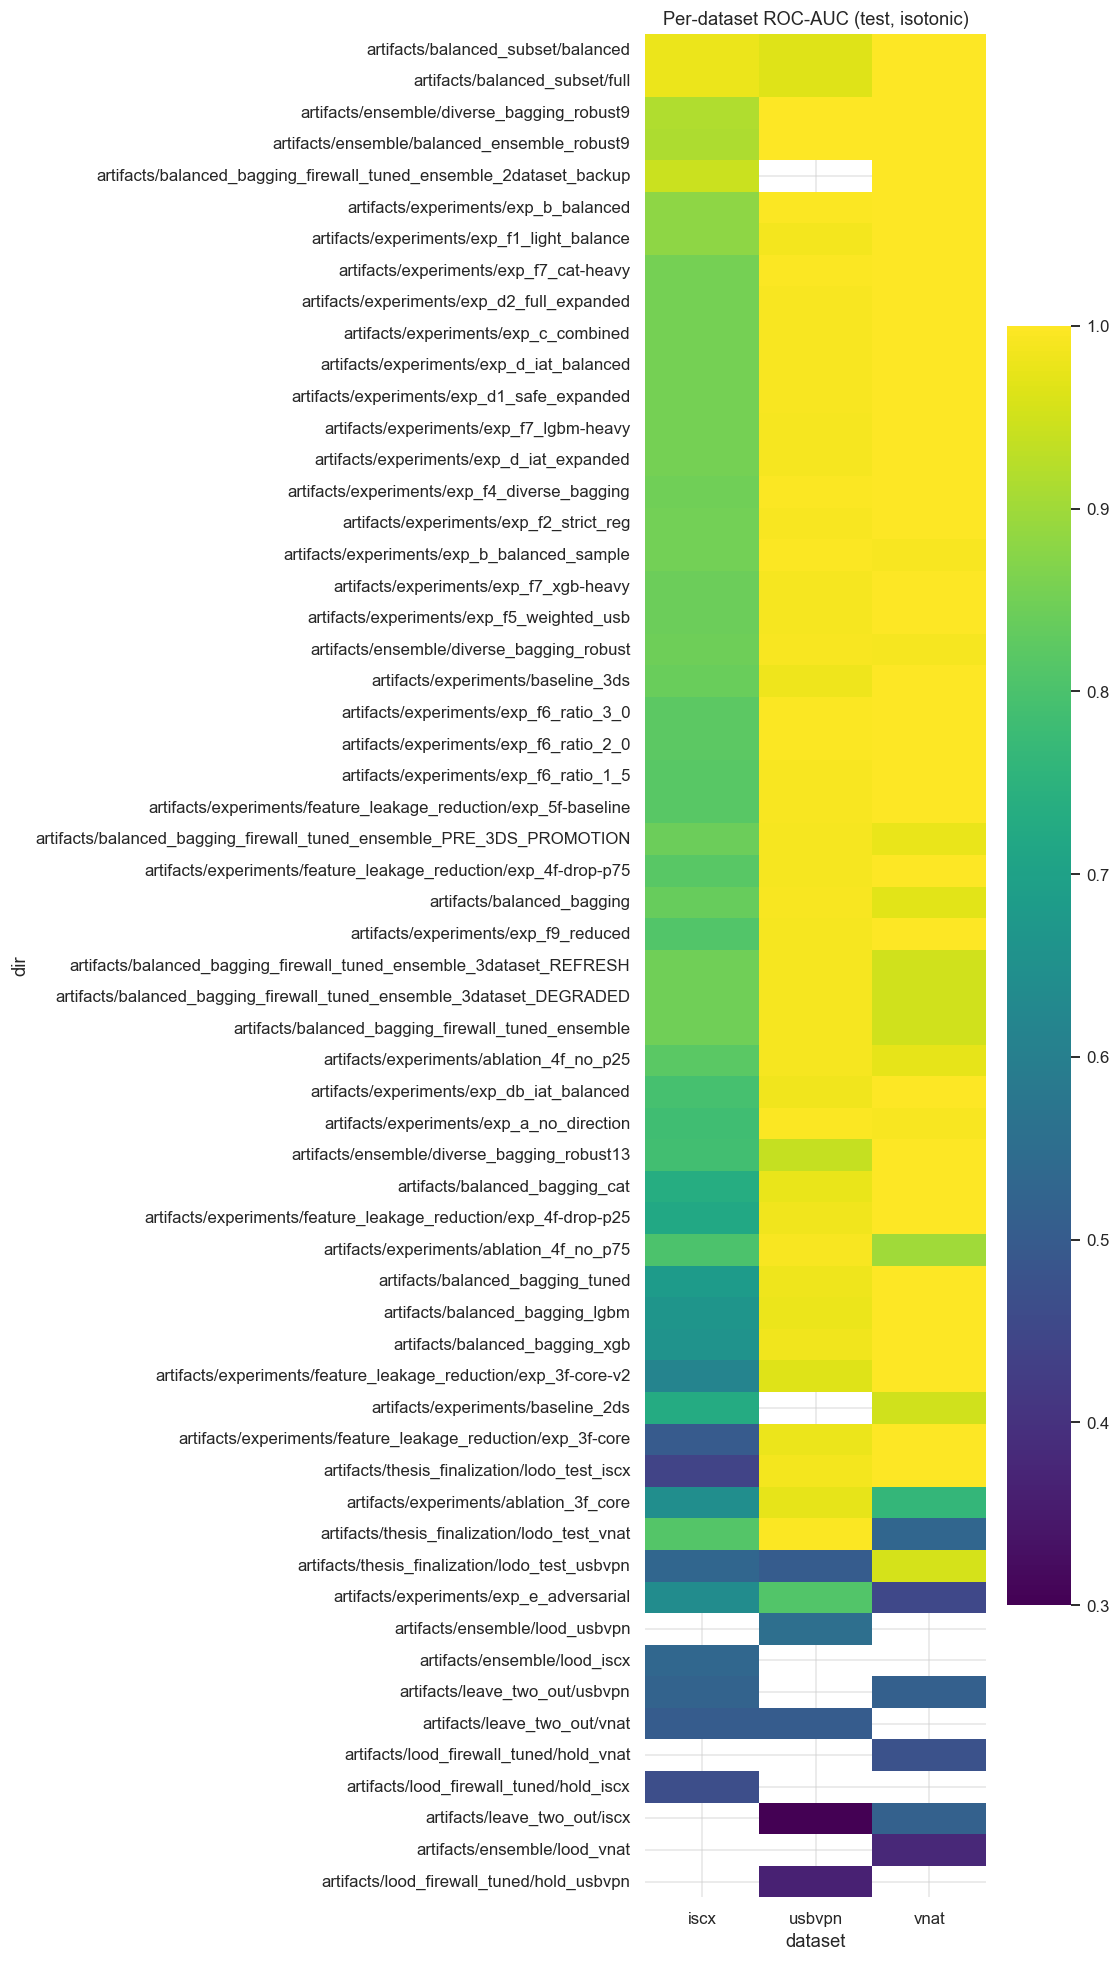

In [6]:
if len(per_ds):
    pivot_auc = per_ds.pivot_table(index='dir', columns='dataset', values='auc_iso', aggfunc='mean')
    pivot_auc = pivot_auc.loc[pivot_auc.mean(axis=1).sort_values(ascending=False).index]

    display(pivot_auc.head(30).round(4))

    fig_h = max(5, min(18, 0.35 * len(pivot_auc)))
    fig, ax = plt.subplots(figsize=(10, fig_h))
    sns.heatmap(pivot_auc, annot=False, cmap='viridis', vmin=0.3, vmax=1.0, ax=ax)
    ax.set_title('Per-dataset ROC-AUC (test, isotonic)')
    plt.tight_layout(); plt.show()
else:
    print('No per-dataset rows found.')


## 6) Distribution checks (split, class, dataset balance)

Split-size summary across all models:


,count,mean,std,min,25%,50%,75%,max
split,,,,,,,,
test,60.0,11732.83,12461.82,407.0,8495.0,8733.0,8733.0,63963.0
train,59.0,37541.17,13784.39,2487.0,31306.0,40583.0,49506.0,57971.0
val,60.0,8016.95,2391.63,412.0,8738.0,8861.0,9022.0,10937.0


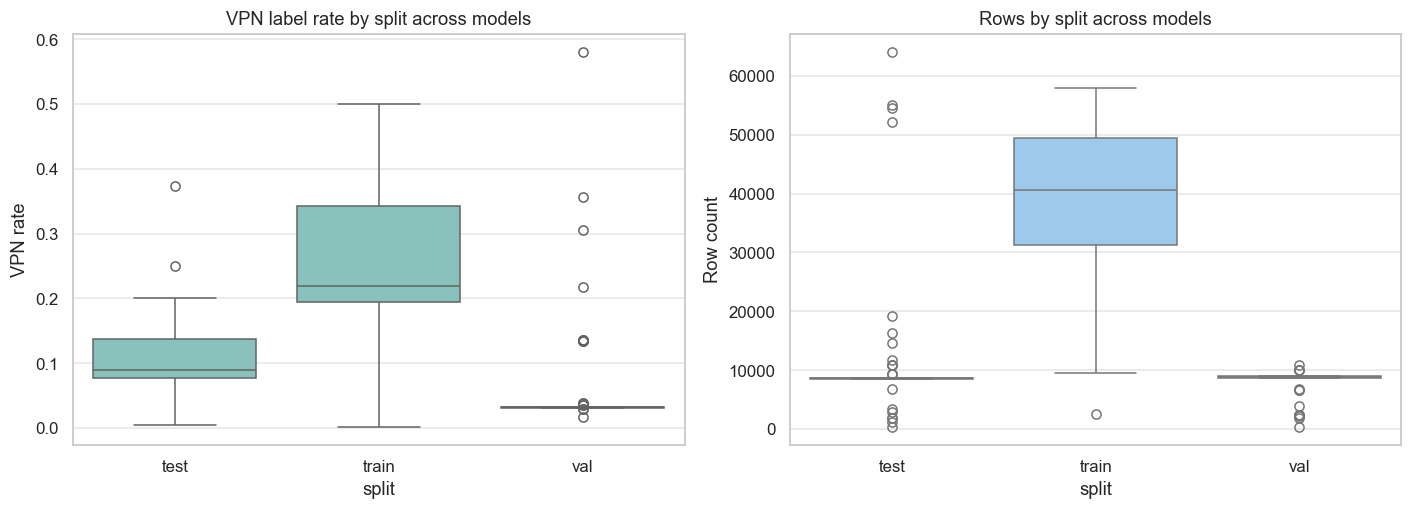

Focus model for detailed distribution: artifacts/ensemble/diverse_bagging_robust9
Split x Dataset counts:


dataset,iscx,usbvpn,vnat
split,,,
test,1634,7540,210
train,8388,35361,7750
val,1779,6749,147


Split x Label stats:


,count,n_vpn,vpn_rate
split,,,
test,9384,1289,0.137361
train,51499,8013,0.155595
val,8675,1178,0.135793


In [7]:
if len(split_sizes):
    print('Split-size summary across all models:')
    display(split_sizes.groupby('split')['n_rows'].describe().round(2))

    fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
    sns.boxplot(data=split_sizes, x='split', y='vpn_rate', ax=axes[0], color='#80CBC4')
    axes[0].set_title('VPN label rate by split across models')
    axes[0].set_ylabel('VPN rate')

    sns.boxplot(data=split_sizes, x='split', y='n_rows', ax=axes[1], color='#90CAF9')
    axes[1].set_title('Rows by split across models')
    axes[1].set_ylabel('Row count')

    plt.tight_layout(); plt.show()

# Focus one model for detailed distribution view
FOCUS_MODEL = ranked.iloc[0]['dir'] if len(ranked) else pred_df.iloc[0]['dir']
print('Focus model for detailed distribution:', FOCUS_MODEL)
focus_path = ROOT / pred_df.loc[pred_df['dir'] == FOCUS_MODEL, 'pred_file'].iloc[0]
focus = read_preds(focus_path)

if 'split' in focus.columns and 'dataset' in focus.columns:
    ct = pd.crosstab(index=[focus['split']], columns=focus['dataset'])
    print('Split x Dataset counts:')
    display(ct)

if 'split' in focus.columns:
    cl = focus.groupby('split')['label'].agg(['count', 'sum', 'mean']).rename(columns={'sum':'n_vpn','mean':'vpn_rate'})
    print('Split x Label stats:')
    display(cl)


## 7) Leakage audit across all models

In [8]:
def id_overlap_count(df: pd.DataFrame, id_col: str, a: str, b: str) -> int:
    if id_col not in df.columns or 'split' not in df.columns:
        return 0
    sa = set(df.loc[df['split'] == a, id_col].dropna().astype(str).unique())
    sb = set(df.loc[df['split'] == b, id_col].dropna().astype(str).unique())
    return int(len(sa & sb))


leak_rows = []
for _, row in pred_df.iterrows():
    model_dir = row['dir']
    df = read_preds(ROOT / row['pred_file'])
    if 'split' not in df.columns:
        continue

    flow_tv = id_overlap_count(df, 'flow_id', 'train', 'val')
    flow_tt = id_overlap_count(df, 'flow_id', 'train', 'test')
    flow_vt = id_overlap_count(df, 'flow_id', 'val', 'test')

    cap_tv = id_overlap_count(df, 'capture_id', 'train', 'val')
    cap_tt = id_overlap_count(df, 'capture_id', 'train', 'test')
    cap_vt = id_overlap_count(df, 'capture_id', 'val', 'test')

    # weak heuristic: suspicious if overlap exists OR near-perfect AUC
    test_iso_auc = np.nan
    if 'prob_iso' in df.columns:
        test = df[df['split'] == 'test']
        if len(test):
            test_iso_auc = safe_auc(test['label'], test['prob_iso'])

    suspicious = (
        (flow_tv + flow_tt + flow_vt + cap_tv + cap_tt + cap_vt) > 0
        or (pd.notna(test_iso_auc) and test_iso_auc >= 0.9999)
    )

    leak_rows.append({
        'dir': model_dir,
        'status': row['status'],
        'flow_overlap_train_val': flow_tv,
        'flow_overlap_train_test': flow_tt,
        'flow_overlap_val_test': flow_vt,
        'capture_overlap_train_val': cap_tv,
        'capture_overlap_train_test': cap_tt,
        'capture_overlap_val_test': cap_vt,
        'test_auc_iso': test_iso_auc,
        'suspicious_flag': bool(suspicious),
    })

leak = pd.DataFrame(leak_rows)
print('Leakage table (top suspicious first):')
display(leak.sort_values(['suspicious_flag', 'flow_overlap_train_test', 'capture_overlap_train_test', 'test_auc_iso'], ascending=[False, False, False, False]).head(40))

print('\nSuspicious models:', int(leak['suspicious_flag'].sum()), '/', len(leak))


Leakage table (top suspicious first):


,dir,status,flow_overlap_train_val,flow_overlap_train_test,flow_overlap_val_test,capture_overlap_train_val,capture_overlap_train_test,capture_overlap_val_test,test_auc_iso,suspicious_flag
16,artifacts/ensemble/diverse_bagging_robust9,3-DS ✅,0,0,0,0,0,0,0.991231,False
26,artifacts/experiments/exp_b_balanced,3-DS ✅,0,0,0,0,0,0,0.988484,False
27,artifacts/experiments/exp_b_balanced_sample,3-DS ✅,0,0,0,0,0,0,0.985881,False
0,artifacts/balanced_bagging,3-DS ✅,0,0,0,0,0,0,0.984563,False
14,artifacts/ensemble/diverse_bagging_robust,3-DS ✅,0,0,0,0,0,0,0.984225,False
35,artifacts/experiments/exp_f1_light_balance,3-DS ✅,0,0,0,0,0,0,0.983370,False
2,artifacts/balanced_bagging_firewall_tuned_ense...,3-DS ✅,0,0,0,0,0,0,0.982501,False
4,artifacts/balanced_bagging_firewall_tuned_ense...,3-DS ✅,0,0,0,0,0,0,0.982501,False
5,artifacts/balanced_bagging_firewall_tuned_ense...,3-DS ✅,0,0,0,0,0,0,0.982501,False
13,artifacts/ensemble/balanced_ensemble_robust9,3-DS ✅,0,0,0,0,0,0,0.982177,False



Suspicious models: 0 / 60


## 8) Export audit outputs

In [9]:
out_dir = REPORTS
out_dir.mkdir(parents=True, exist_ok=True)

metrics_out = out_dir / 'all_models_metrics_comparison.csv'
perds_out = out_dir / 'all_models_per_dataset_metrics.csv'
leak_out = out_dir / 'all_models_leakage_checks.csv'
dist_out = out_dir / 'all_models_split_distribution.csv'

metrics.sort_values(['split', 'calibration', 'auc'], ascending=[True, True, False]).to_csv(metrics_out, index=False)
per_ds.sort_values(['dataset', 'auc_iso'], ascending=[True, False]).to_csv(perds_out, index=False)
leak.sort_values(['suspicious_flag', 'flow_overlap_train_test', 'capture_overlap_train_test'], ascending=[False, False, False]).to_csv(leak_out, index=False)
split_sizes.to_csv(dist_out, index=False)

print('Wrote:')
print('-', metrics_out.relative_to(ROOT))
print('-', perds_out.relative_to(ROOT))
print('-', leak_out.relative_to(ROOT))
print('-', dist_out.relative_to(ROOT))


Wrote:
- reports\tables\all_models_metrics_comparison.csv
- reports\tables\all_models_per_dataset_metrics.csv
- reports\tables\all_models_leakage_checks.csv
- reports\tables\all_models_split_distribution.csv


## Notes on interpretation
- A high score alone is **not leakage proof**; use overlap checks and experiment design context.
- LODO / leave-two-out runs intentionally have different dataset coverage.
- The strongest hard leakage signal is non-zero `flow_id` or `capture_id` overlap across splits.
- If needed, extend checks with feature-level near-duplicate hashing on raw flow tables.


---
_End of notebook._